In [7]:
"""
Automatically reloads libraries and utilities every time a cell is run
"""
%load_ext autoreload
%autoreload 2

In [8]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.PSF_helpers import *
from utils.Plot_helpers import *
from utils.Zernike_helpers import *
from utils.Booth_helpers import *

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [9]:
#minor style things to make the figures look nice
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

In [10]:
N_order = 3                # 3 for 3P, 2 for 2P
lambd = 1.3e-3             # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.05             # Numerical aperture
f = 7.2                    # Focal length of objective (Olympus) [mm]
theta_grid_size = 64            # BFP resolution
L_bfp = 15.12              # BFP diameter [mm]
mag = 4                    # Magnification rate from input to objective
w_0 = 3.5                  # mm
num_apt = 1.05

In [117]:
r_pupil = f * num_apt
r_bfp = L_bfp / 2
na_eff = num_apt
#effective NA can be limited by the size of the back focal plane
if r_bfp < r_pupil:
    na_eff = r_bfp / f
alpha = np.arcsin(na_eff / n)

R_BFP = r_bfp

microscope = Microscope(N_order, lambd, n, num_apt, f, mag, w_0, L_bfp, theta_grid_size)
L_ffp = 0.002
grid_ffp = 64
grid = Centered_Square_Grid(L_ffp, grid_ffp, 0)
bead_img = Bead_Image(grid, [0.000], [0.000], [0.0002])
true_modes = [[-2, 2],
                         [0, 4]]
true_c = [0.1,
                                   0.1]
aberration = Aberration(true_modes, true_c)

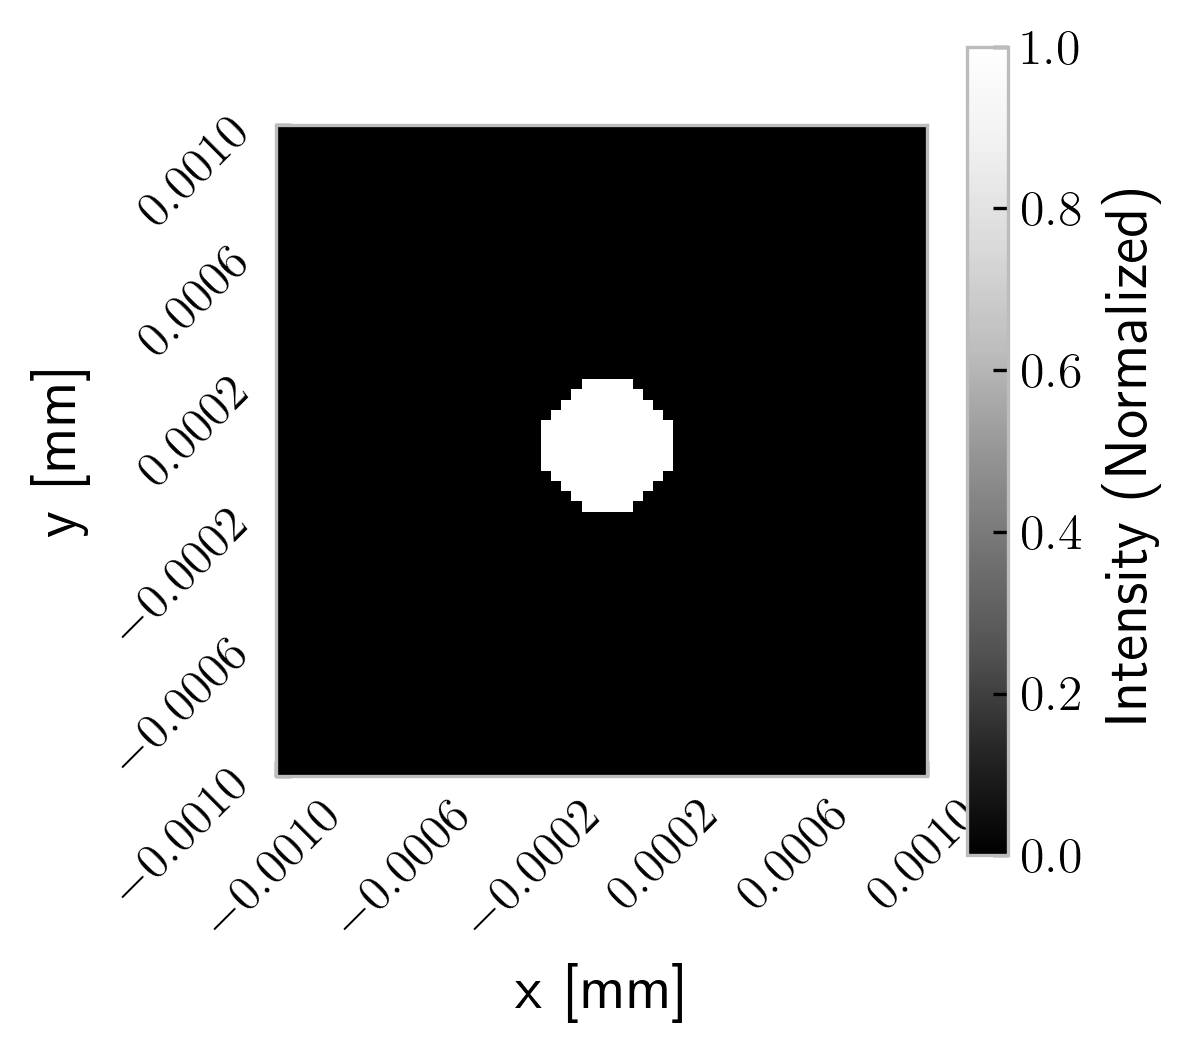

In [118]:
plot_intensity(*bead_img.get_xy(), bead_img.image_mask)
X = bead_img.image_mask

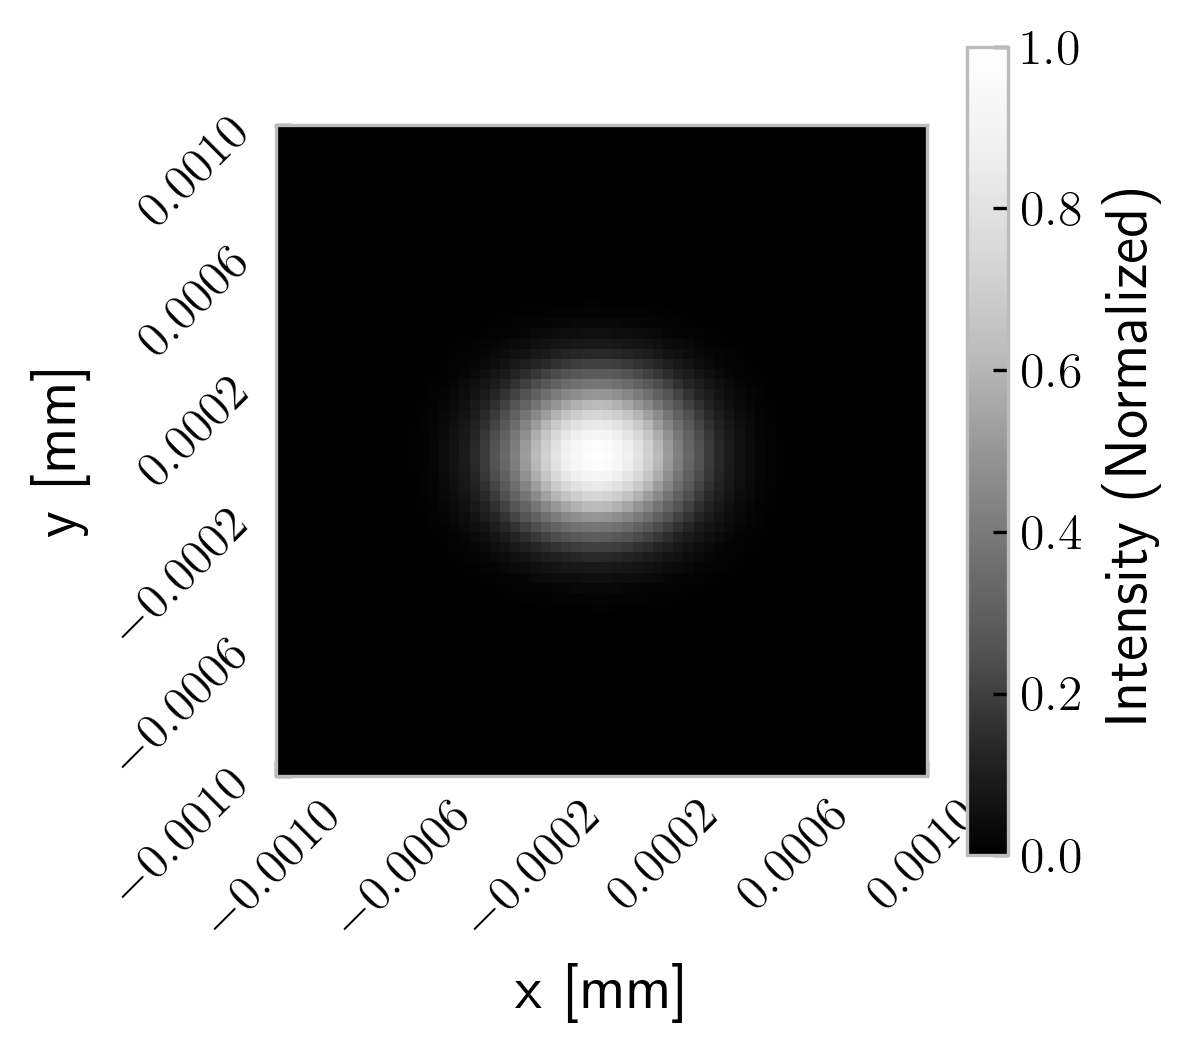

In [119]:
x, y, PSF = microscope.compute_PSF(grid, aberration)
plot_intensity(x, y, PSF)

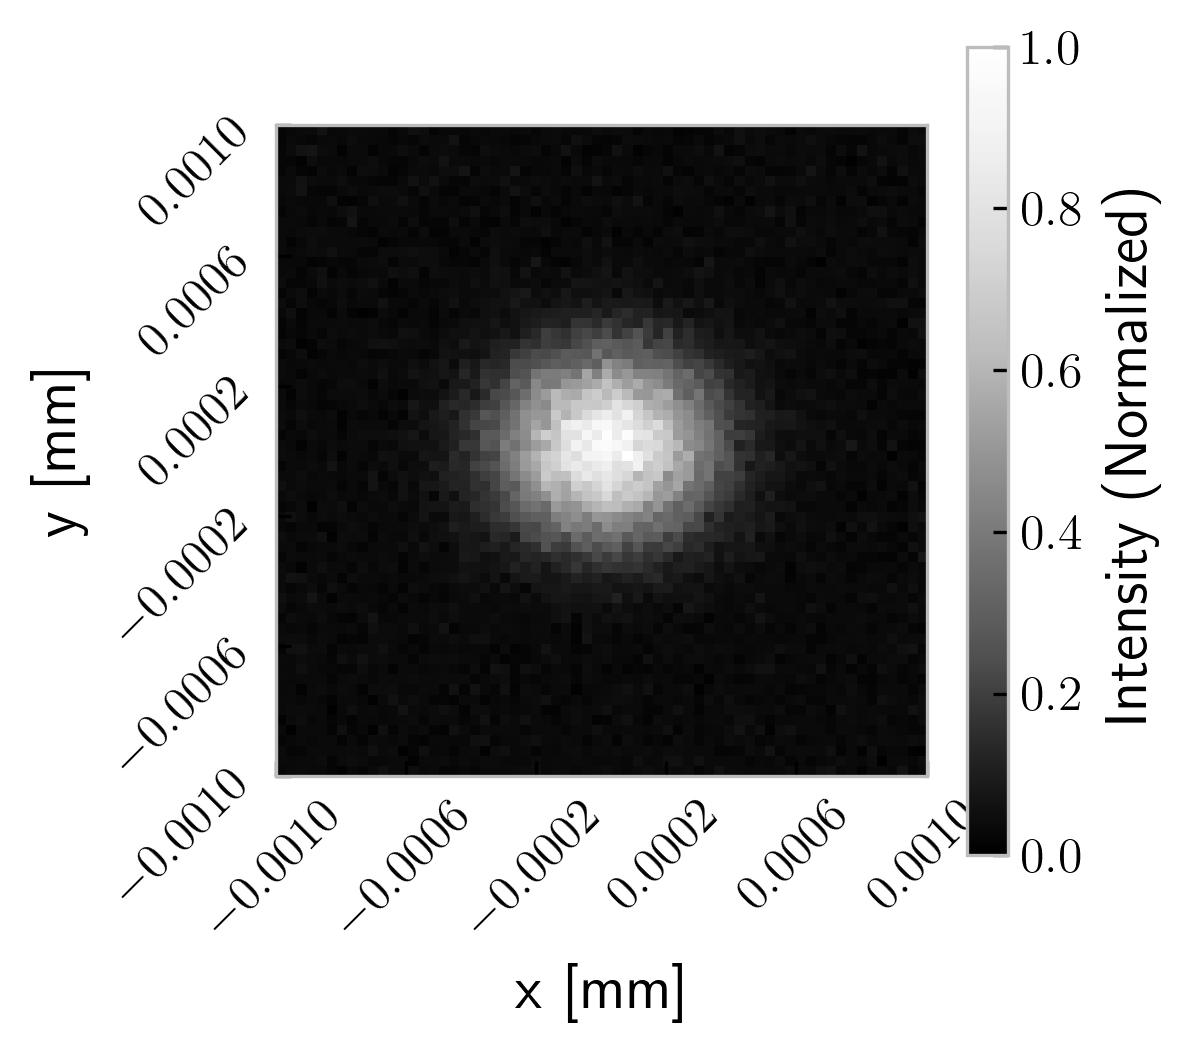

In [120]:
exposure = 500
background = 10
rng = np.random.default_rng(15)
Y = rng.poisson(psf_convolve(X, PSF) * exposure + background)
plot_intensity(x, y, Y)

In [180]:
#Y/Y_hat is the convolved image
#a_hat is the estimated aberrations
#X is the known image mask

def compute_prediction(X, a_modes, a, background, exposure):
    _, _, PSF = microscope.compute_PSF(grid, Aberration(a_modes.tolist(), a.tolist()))
    Y_hat = psf_convolve(X, PSF) * exposure + background
    #ensure positive values
    Y_hat = np.clip(Y_hat, 0, np.inf)
    return Y_hat

def log_a_prior(a):
    #a_hat must be between 0 and 1
    if np.any(a < 0) or np.any(a > 1):
        return -np.inf
    return 0

#poisson likelihood
def cash(Y, Y_hat):
    #ensure positive values
    Y_hat = np.clip(Y_hat, 1e-25, np.inf)
    stat = 2 * (Y_hat - Y * np.log(Y_hat))
    return stat

def log_likelihood(X, Y, a_modes, a, background, exposure):
    Y_hat = compute_prediction(X, a_modes, a, background, exposure)
    return cash(Y, Y_hat).sum()

def log_posterior(X, Y, a_modes, a, background, exposure):
    return log_a_prior(a) + log_likelihood(
        X = X, Y = Y, a_modes = a_modes, a = a, background=background, exposure=exposure
    )

def random_coin(p):
    unif = np.random.uniform(0, 1)
    return unif <= p

In [181]:
def deconvolve_mcmc_a(X_init, Y, a_modes, a_init, background, exposure, n_samples):
    a_trace = np.zeros((n_samples, len(a_modes)))
    log_post_trace = np.zeros(n_samples)
    rng = np.random.default_rng(15)
    for i in tqdm(range(n_samples)):
        #add gaussian noise to the aberration coefficients
        a_hat = a_init + rng.normal(0, 0.01, len(a_init))
        prob = log_posterior(X=X_init, 
                             Y = Y,
                             a_modes = a_modes,
                             a = a_hat,
                             background = background,
                             exposure = exposure)
        prob_init = log_posterior(X=X_init, 
                             Y = Y,
                             a_modes = a_modes,
                             a = a_init,
                             background = background,
                             exposure = exposure)

        acceptance = min(np.exp(prob_init - prob), 1)

        if random_coin(acceptance) and np.isfinite(prob):
            a_init = a_hat

        a_trace[i] = a_init
        log_post_trace[i] = prob

    return {
        "a-trace": a_trace,
        "log-posterior-trace": log_post_trace,
    }

In [143]:
#Y/Y_hat is the convolved image
#a_hat is the estimated aberrations
#X is the known image mask

def compute_prediction_with_PSF(X, PSF, background, exposure):
    Y_hat = psf_convolve(X, PSF) * exposure + background
    #ensure positive values
    Y_hat = np.clip(Y_hat, 0, np.inf)
    return Y_hat

def log_X_prior(X, eps = 1e-5):
    
    dx = np.zeros_like(X)
    dy = np.zeros_like(X)

    dx[:-1, :] = X[1:, :] - X[:-1, :]   # vertical gradient
    dy[:, :-1] = X[:, 1:] - X[:, :-1]   # horizontal gradient

    grad_norm_sq = dx**2 + dy**2

    return np.sum(np.sqrt(grad_norm_sq + eps**2))

#poisson likelihood
def cash(Y, Y_hat):
    #ensure positive values
    Y_hat = np.clip(Y_hat, 1e-25, np.inf)
    stat = 2 * (Y_hat - Y * np.log(Y_hat))
    return stat

def log_likelihood_with_PSF(X, Y, PSF, background, exposure):
    Y_hat = compute_prediction_with_PSF(X, PSF, background, exposure)
    return cash(Y, Y_hat).sum()

def log_posterior_with_PSF(X, Y, PSF, background, exposure):
    return 10 * log_X_prior(X) + log_likelihood_with_PSF(
        X = X, Y = Y, PSF = PSF, background=background, exposure=exposure
    )

def random_coin(p):
    unif = np.random.uniform(0, 1)
    return unif <= p

In [144]:
def deconvolve_mcmc_X(X_init, Y, a_modes, a_init, background, exposure, n_samples):
    X_trace = np.zeros((n_samples, len(X_init), len(X_init)))
    log_post_trace = np.zeros(n_samples)
    rng = np.random.default_rng(15)

    _, _, PSF = microscope.compute_PSF(grid, Aberration(a_modes.tolist(), a_init.tolist()))
    for i in tqdm(range(n_samples)):
        #swap a random pixel in X 
        X_hat = np.copy(X_init) 
        for k in range(1):
             a = int(np.floor(rng.uniform(0, len(X_hat))))
             b = int(np.floor(rng.uniform(0, len(X_hat))))
             X_hat[a, b] = 1 - X_hat[a, b]

        prob = log_posterior_with_PSF(X=X_hat, 
                             Y = Y,
                             PSF = PSF,
                             background = background,
                             exposure = exposure)
        prob_init = log_posterior_with_PSF(X=X_init, 
                             Y = Y,
                             PSF = PSF,
                             background = background,
                             exposure = exposure)

        acceptance = min(np.exp(prob_init - prob), 1)

        if random_coin(acceptance) and np.isfinite(prob):
            X_init = X_hat

        X_trace[i] = X_init
        log_post_trace[i] = prob

    return {
        "X-trace": X_trace,
        "log-posterior-trace": log_post_trace,
    }

Blind deconvolution algorithm
First step: assuming 0 aberration, compute the image

In [145]:
a_modes = np.array([[-2, 2],
                    [0,4]])
a_init = np.array([0.0, 0.0])
X_init = np.zeros_like(X)
n_samples = 50000

result_X_0 = deconvolve_mcmc_X(
    X_init= X_init,
    Y = Y,
    n_samples=n_samples,
    a_init = a_init,
    a_modes = a_modes,
    exposure = exposure,
    background = background
)

100%|██████████| 50000/50000 [00:46<00:00, 1071.94it/s]


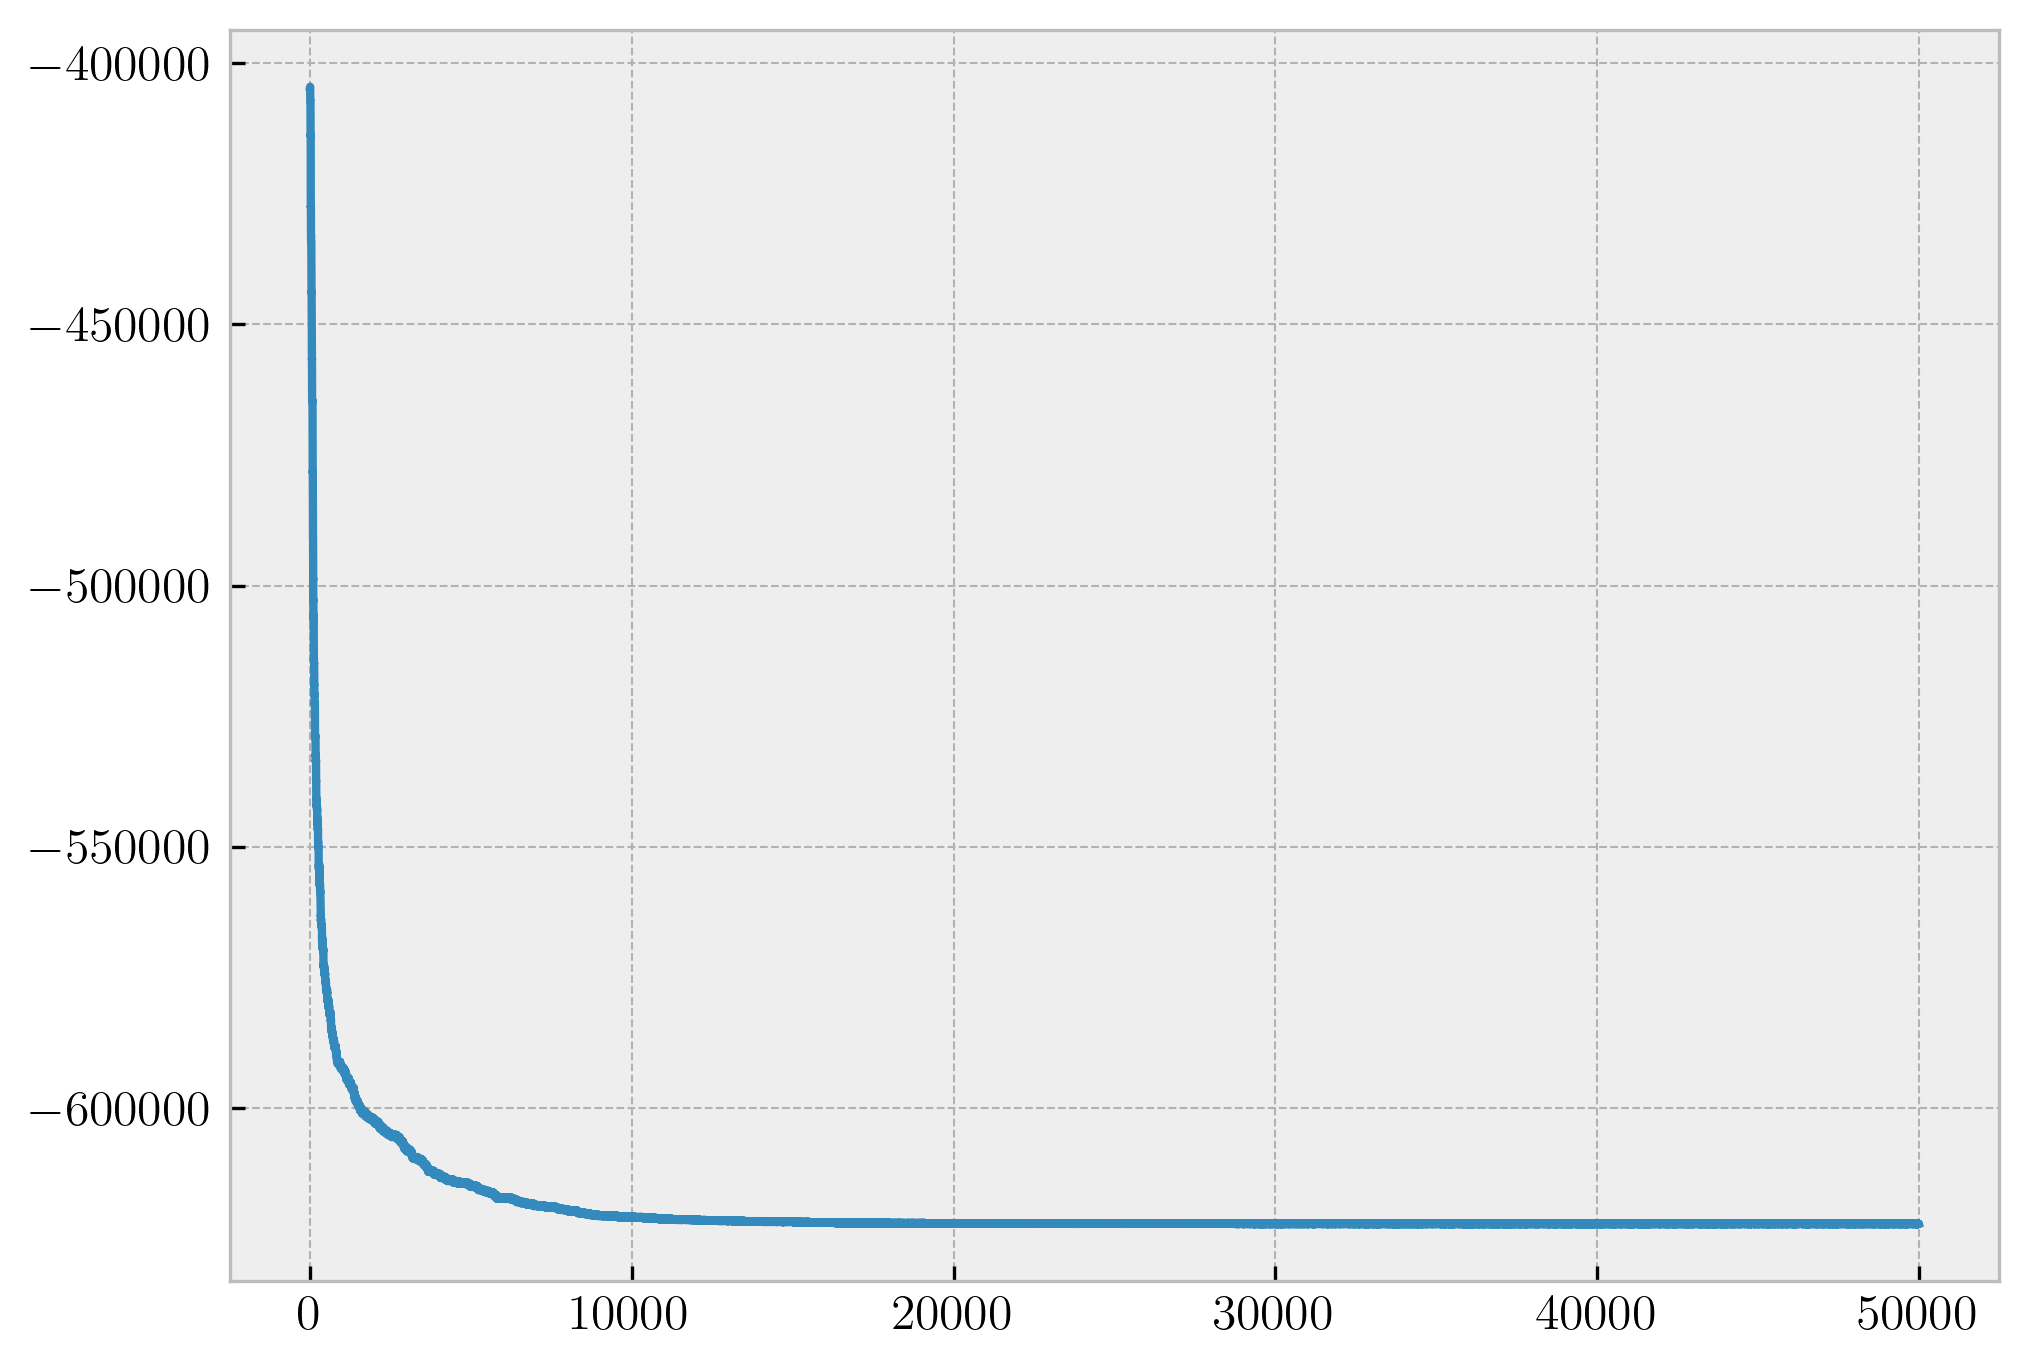

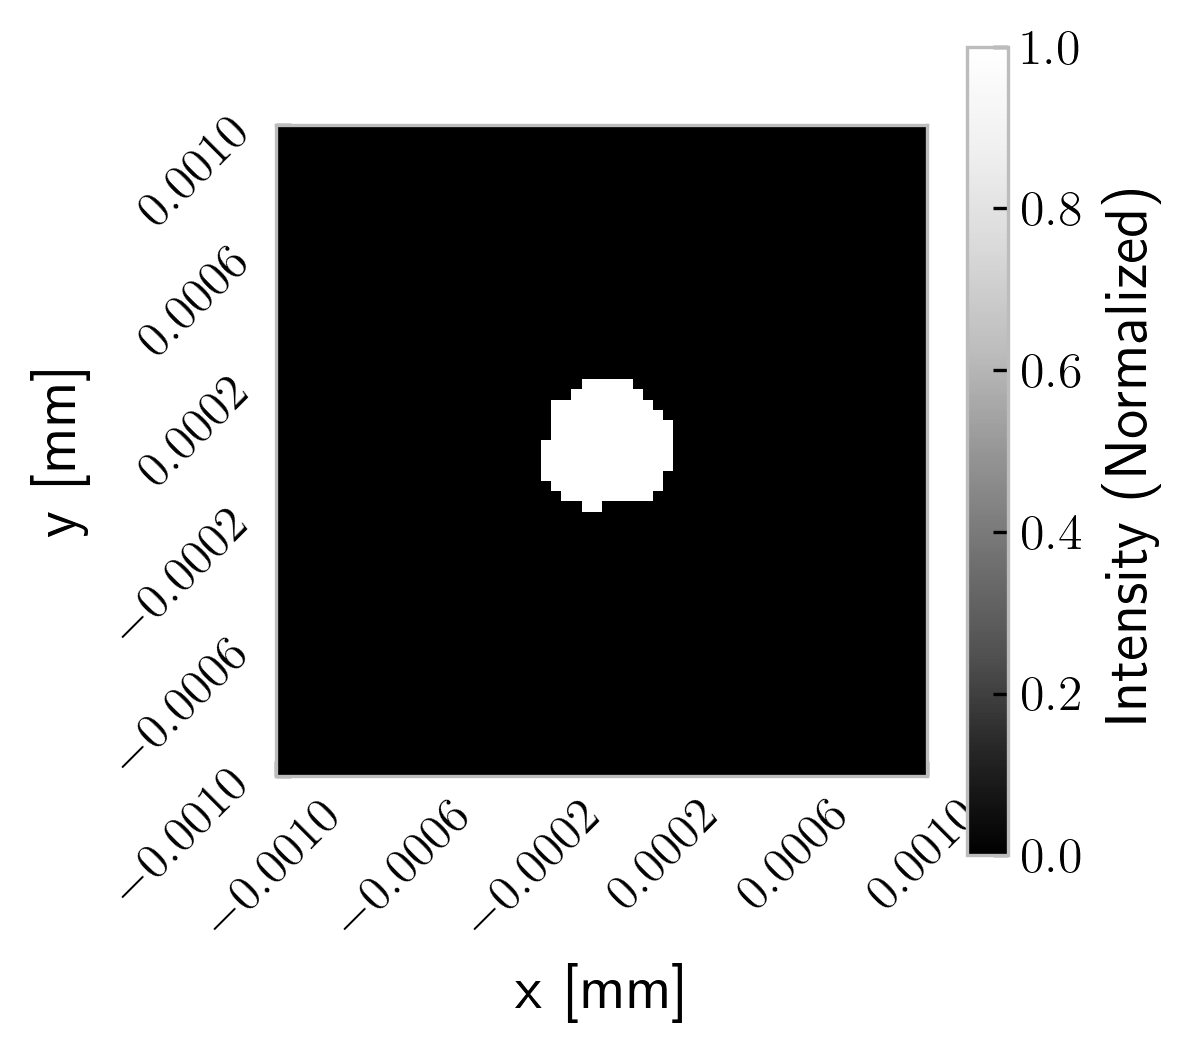

In [146]:
burn_in = 30000

t = np.arange(0, n_samples)
plt.plot(t, result_X_0["log-posterior-trace"])
plt.show()
X_estimated = np.median(result_X_0["X-trace"][-burn_in:], axis = 0)
plot_intensity(x, y, X_estimated)
plt.show()

Step 2: estimating the PSF using the X estimate


In [182]:
a_modes = np.array([[-2, 2],
                    [0,4]])
a_init = np.array([0, 0])
X_init = X_estimated
n_samples = 2000
result_a_0 = deconvolve_mcmc_a(
    X_init= X_init,
    Y = Y,
    n_samples=n_samples,
    a_init = a_init,
    a_modes = a_modes,
    exposure = exposure,
    background = background
)

100%|██████████| 2000/2000 [00:23<00:00, 84.29it/s] 


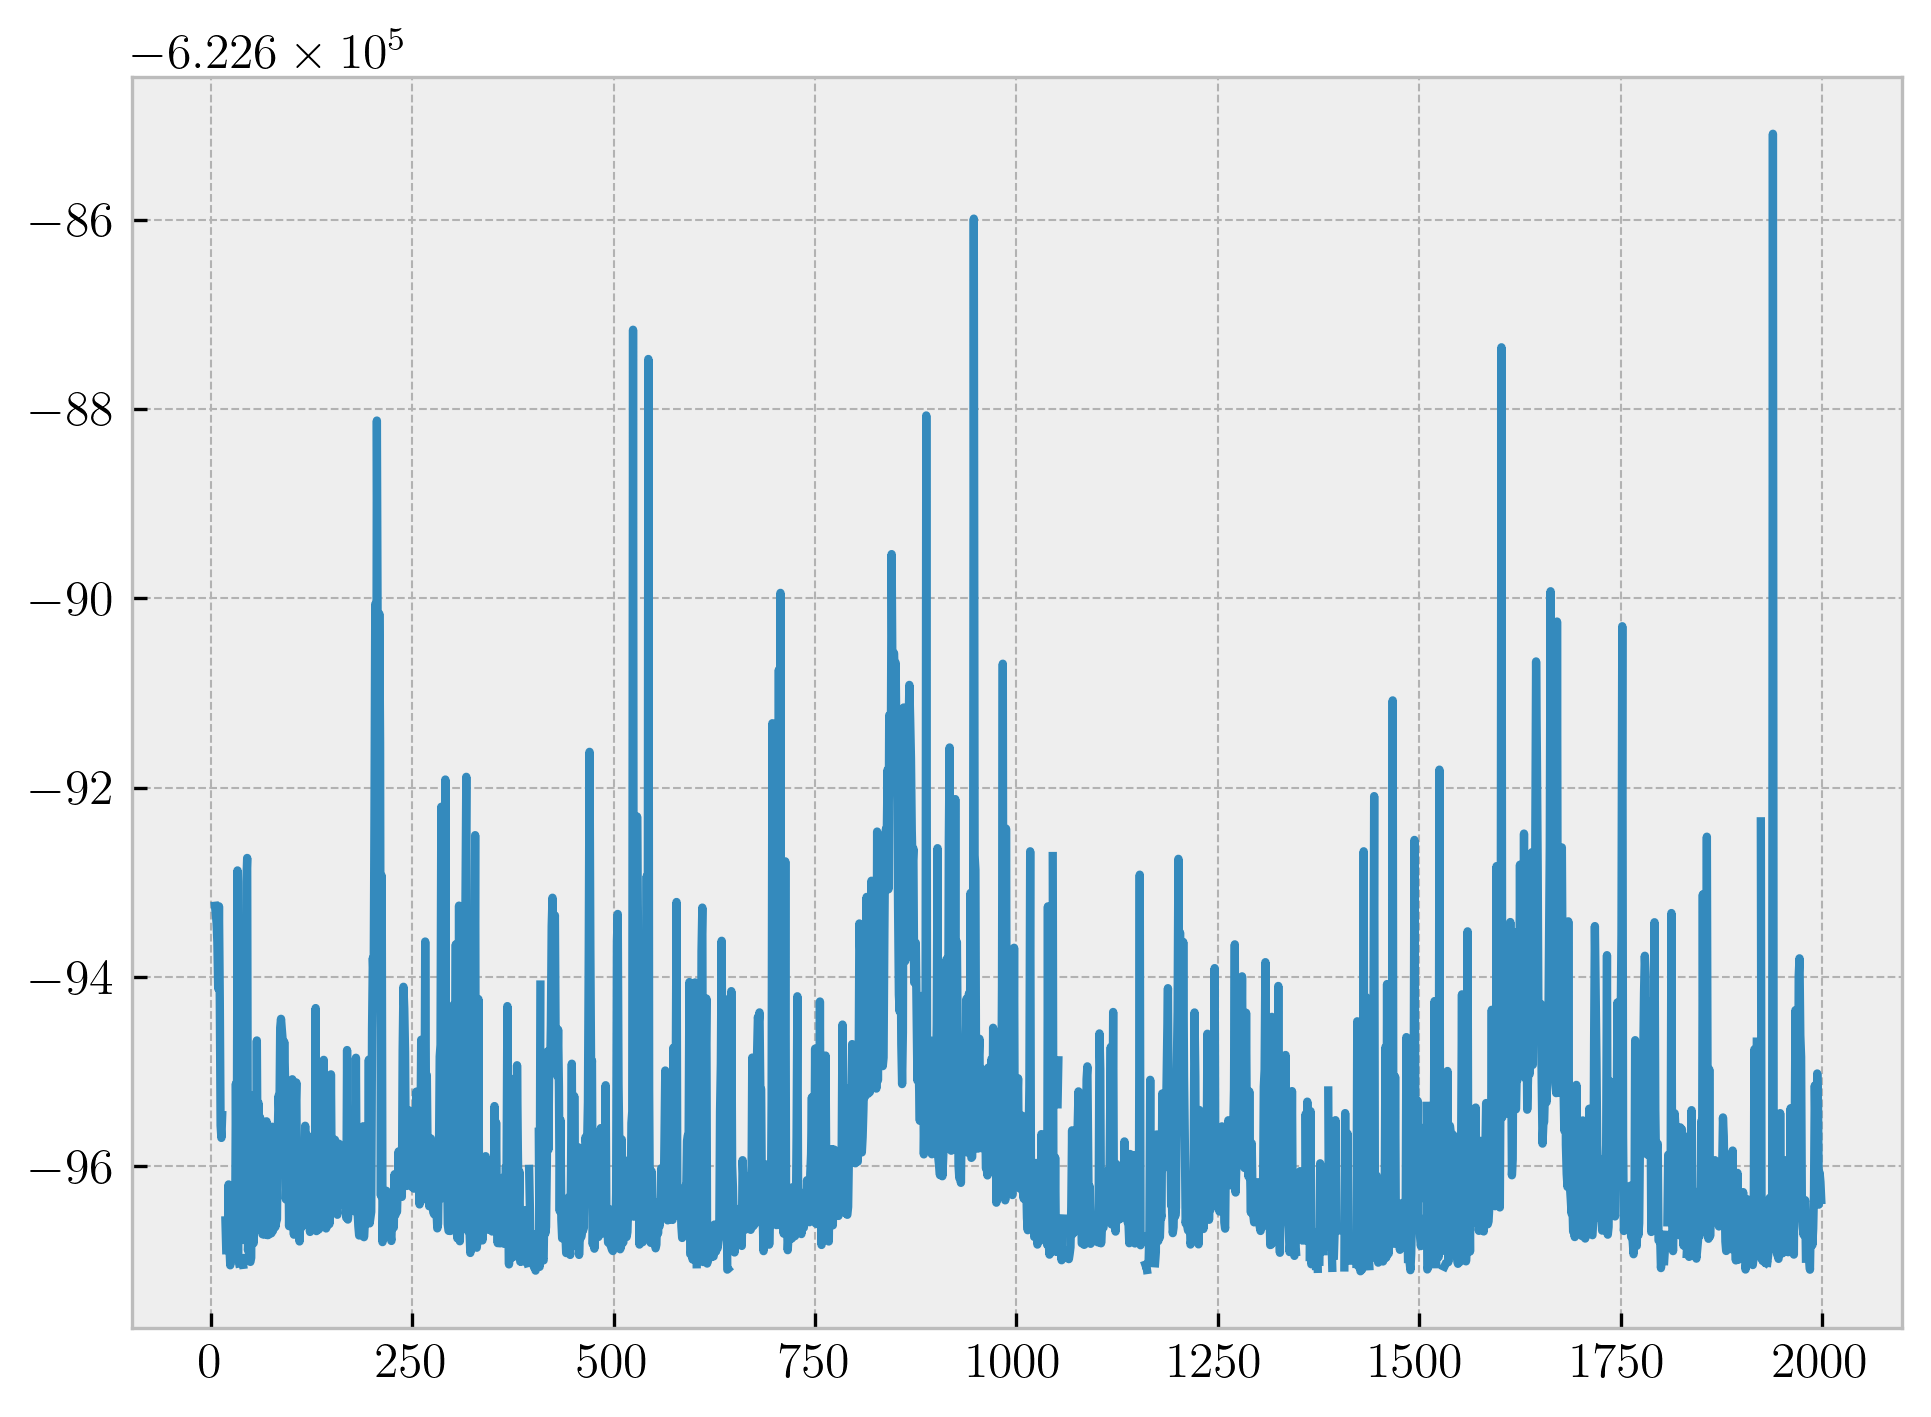

In [183]:
t = np.arange(0, n_samples)
plt.plot(t, result_a_0["log-posterior-trace"])

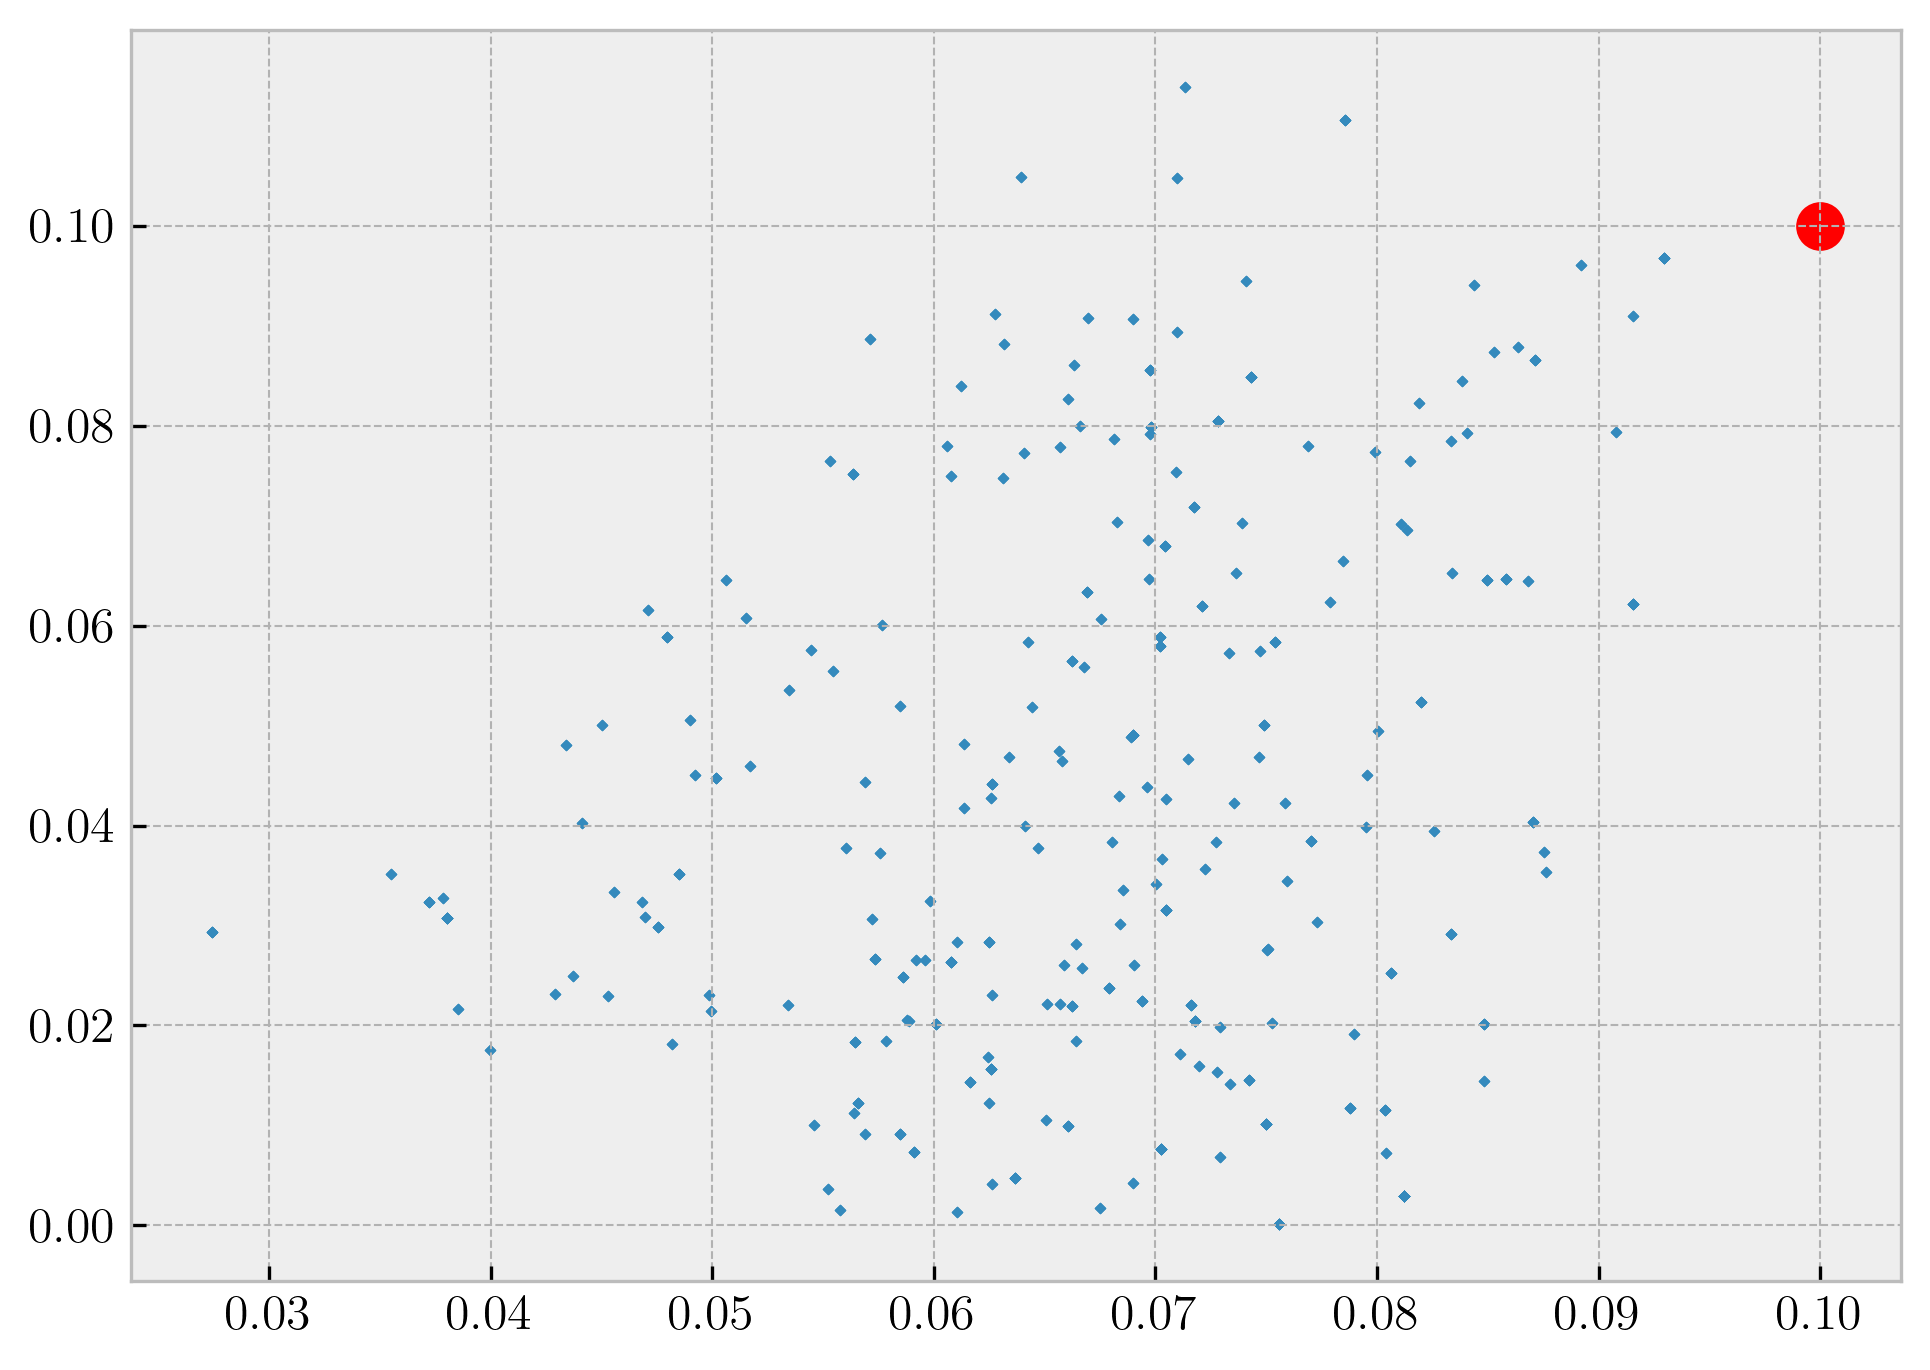

In [184]:
burn_in = 300
multi_data = result_a_0["a-trace"][-burn_in:]
mode_1 = result_a_0["a-trace"][:, 0][-burn_in:]
mode_2 = result_a_0["a-trace"][:, 1][-burn_in:]
fig, ax = plt.subplots(dpi = 300)
ax.scatter(mode_1, mode_2, marker = "x", s = 2)
ax.scatter(true_c[0], true_c[1], marker = ".", s = 500, c = "red")

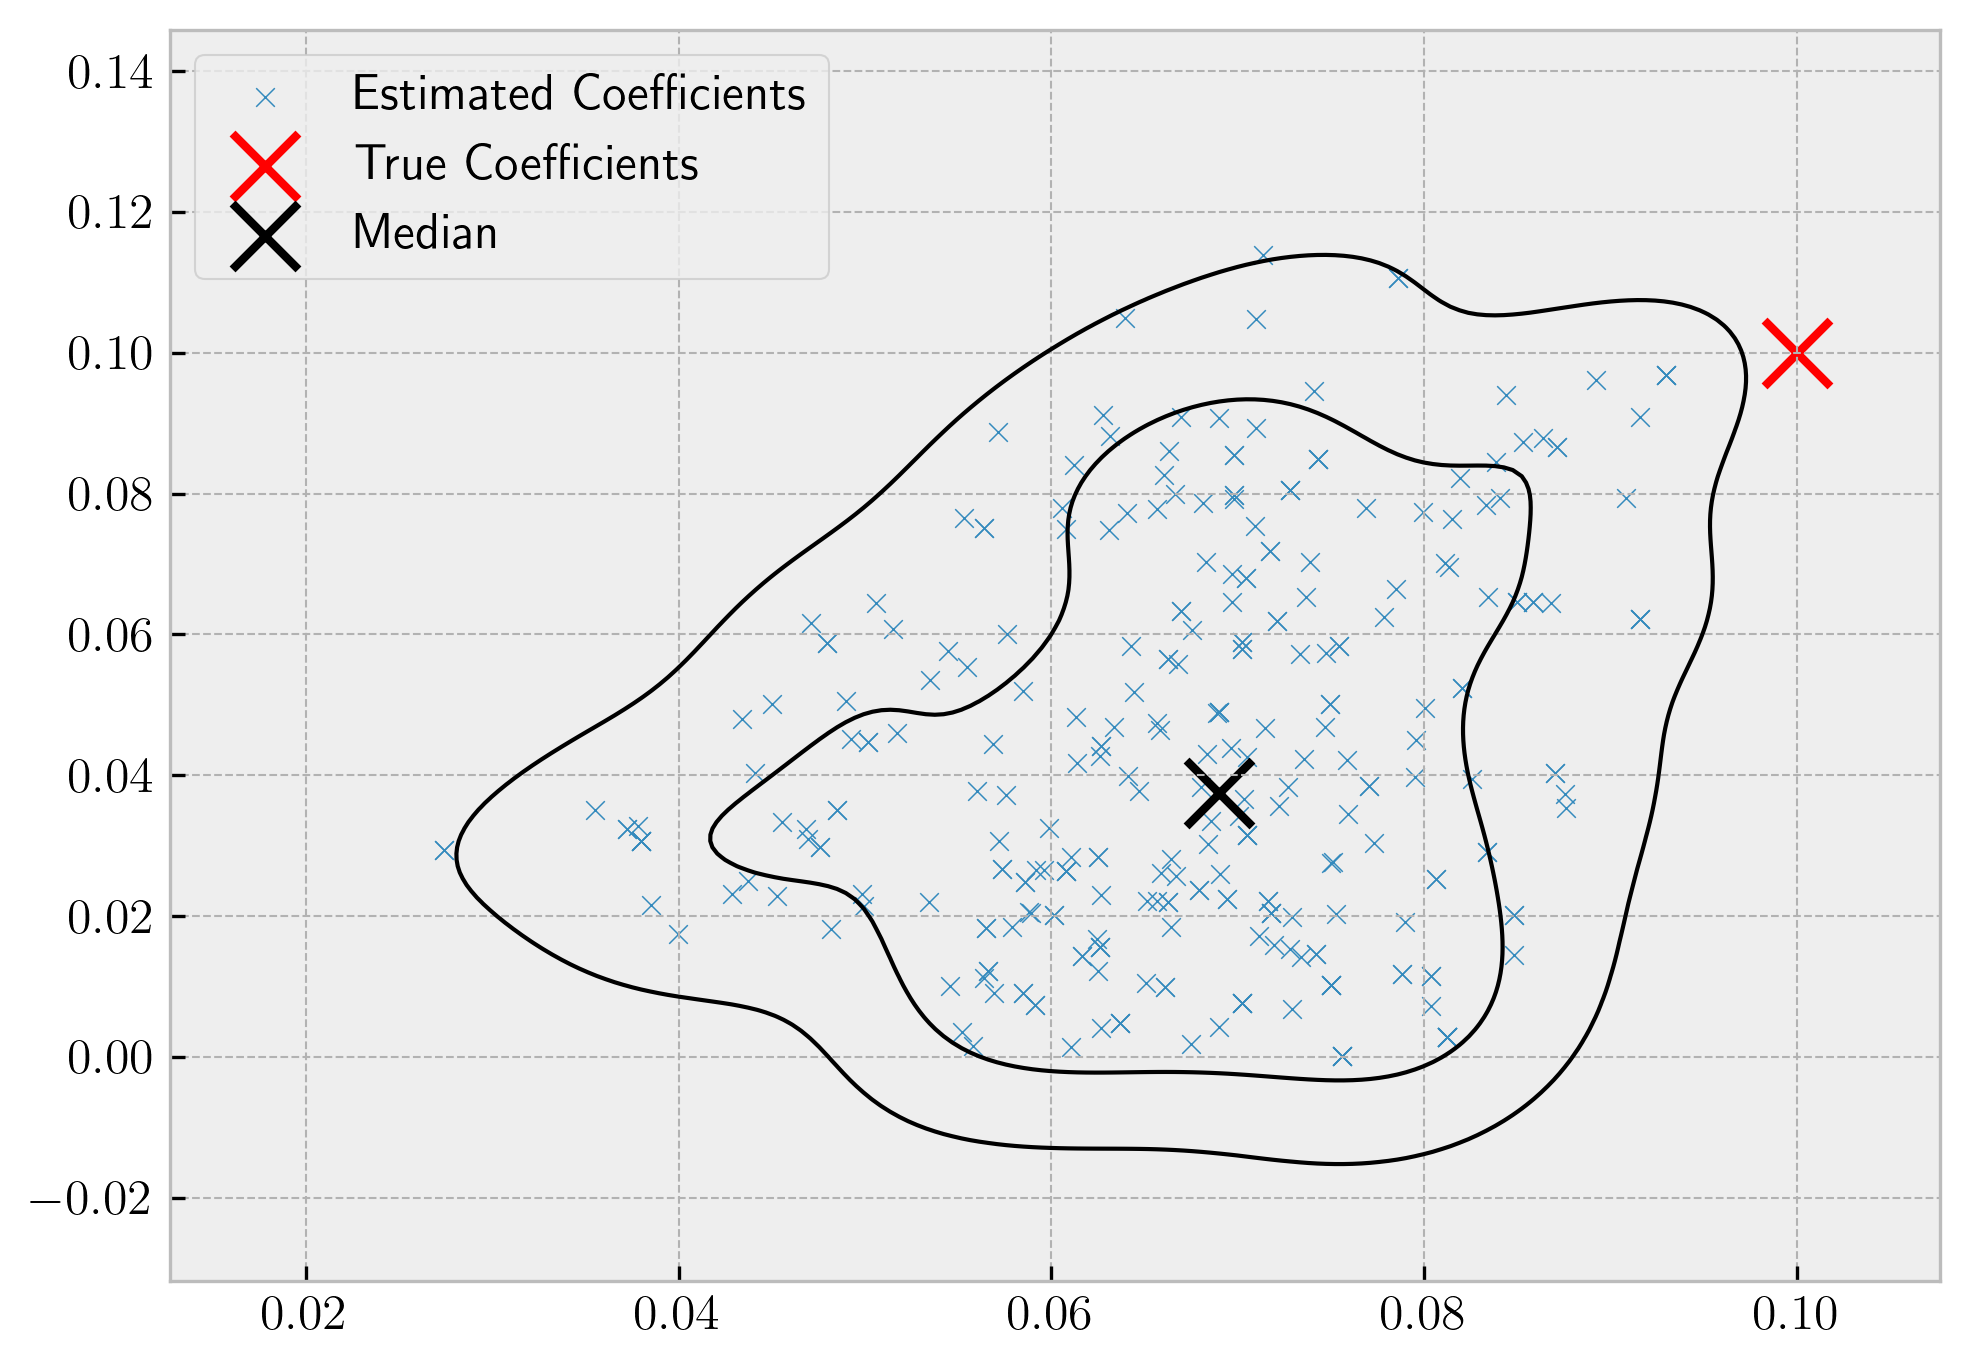

In [185]:
import seaborn as sns
fig, ax = plt.subplots()
sns.scatterplot(x=mode_1, y=mode_2, alpha=1.0, marker = "x", s = 20,
                ax = ax, label = "Estimated Coefficients")
sns.kdeplot(x=mode_1, y=mode_2, levels=[.05, 0.33], color="black", linewidths=1,
            ax = ax, label = "Contours")
ax.scatter(x=true_c[0], y=true_c[1], s = 250, marker = "x", c = "red", label = "True Coefficients")
ax.scatter(x= np.median(mode_1), y = np.median(mode_2), color = "black", label = "Median", marker = "x", s = 250)
ax.set_xlabel("")
ax.legend()


Step 3: recalibrating the X estimate

In [187]:
a_estimate = np.median(multi_data[-burn_in:], axis = 0)

a_modes = np.array([[-2, 2],
                    [0,4]])
a_init = a_estimate
X_init = X_estimated
n_samples = 50000

result_X_1 = deconvolve_mcmc_X(
    X_init= X_init,
    Y = Y,
    n_samples=n_samples,
    a_init = a_init,
    a_modes = a_modes,
    exposure = exposure,
    background = background
)

100%|██████████| 50000/50000 [00:51<00:00, 975.86it/s] 


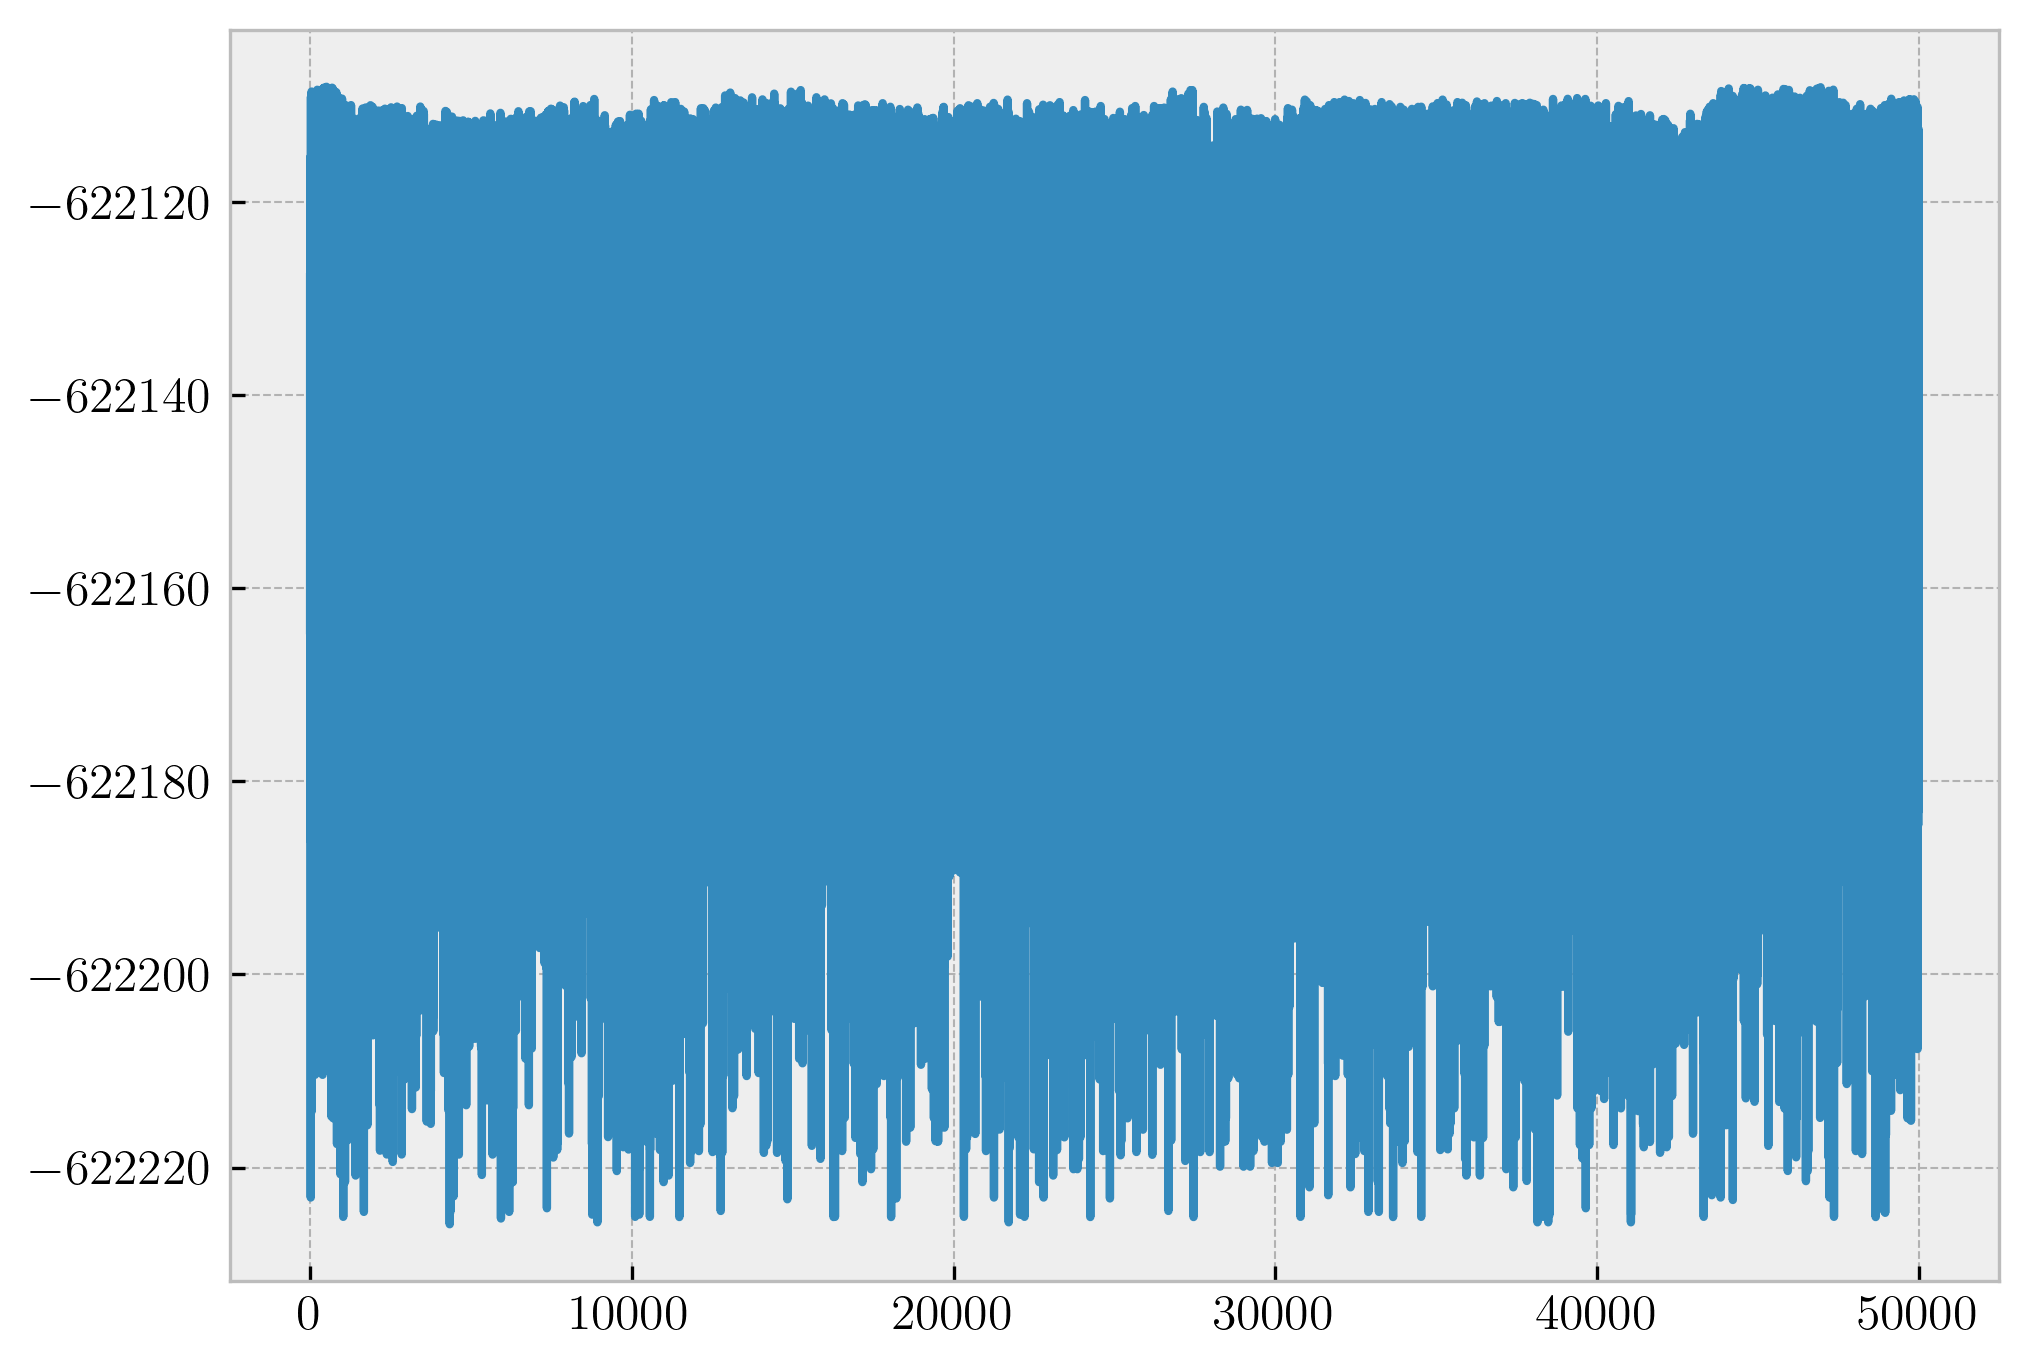

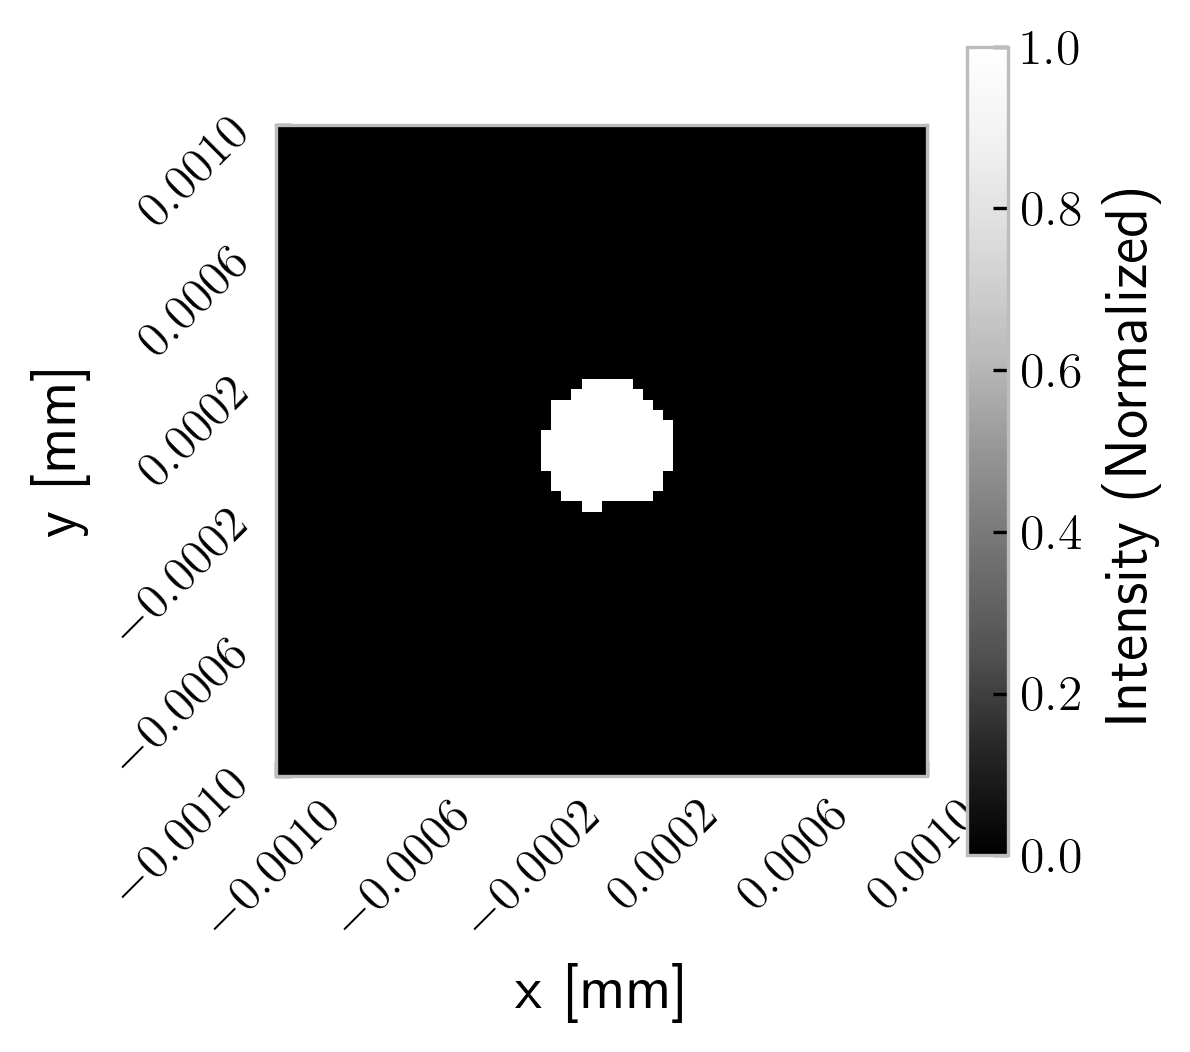

In [188]:
burn_in = 30000

t = np.arange(0, n_samples)
plt.plot(t, result_X_1["log-posterior-trace"])
plt.show()
X_estimated_1 = np.median(result_X_1["X-trace"][-burn_in:], axis = 0)
plot_intensity(x, y, X_estimated_1)
plt.show()

Step 4: re estimating a using the new X estimate


In [190]:
a_modes = np.array([[-2, 2],
                    [0,4]])
a_init = a_estimate
X_init = X_estimated_1
n_samples = 2000
result_a_1 = deconvolve_mcmc_a(
    X_init= X_init,
    Y = Y,
    n_samples=n_samples,
    a_init = a_init,
    a_modes = a_modes,
    exposure = exposure,
    background = background
)

  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:39<00:00, 51.19it/s]


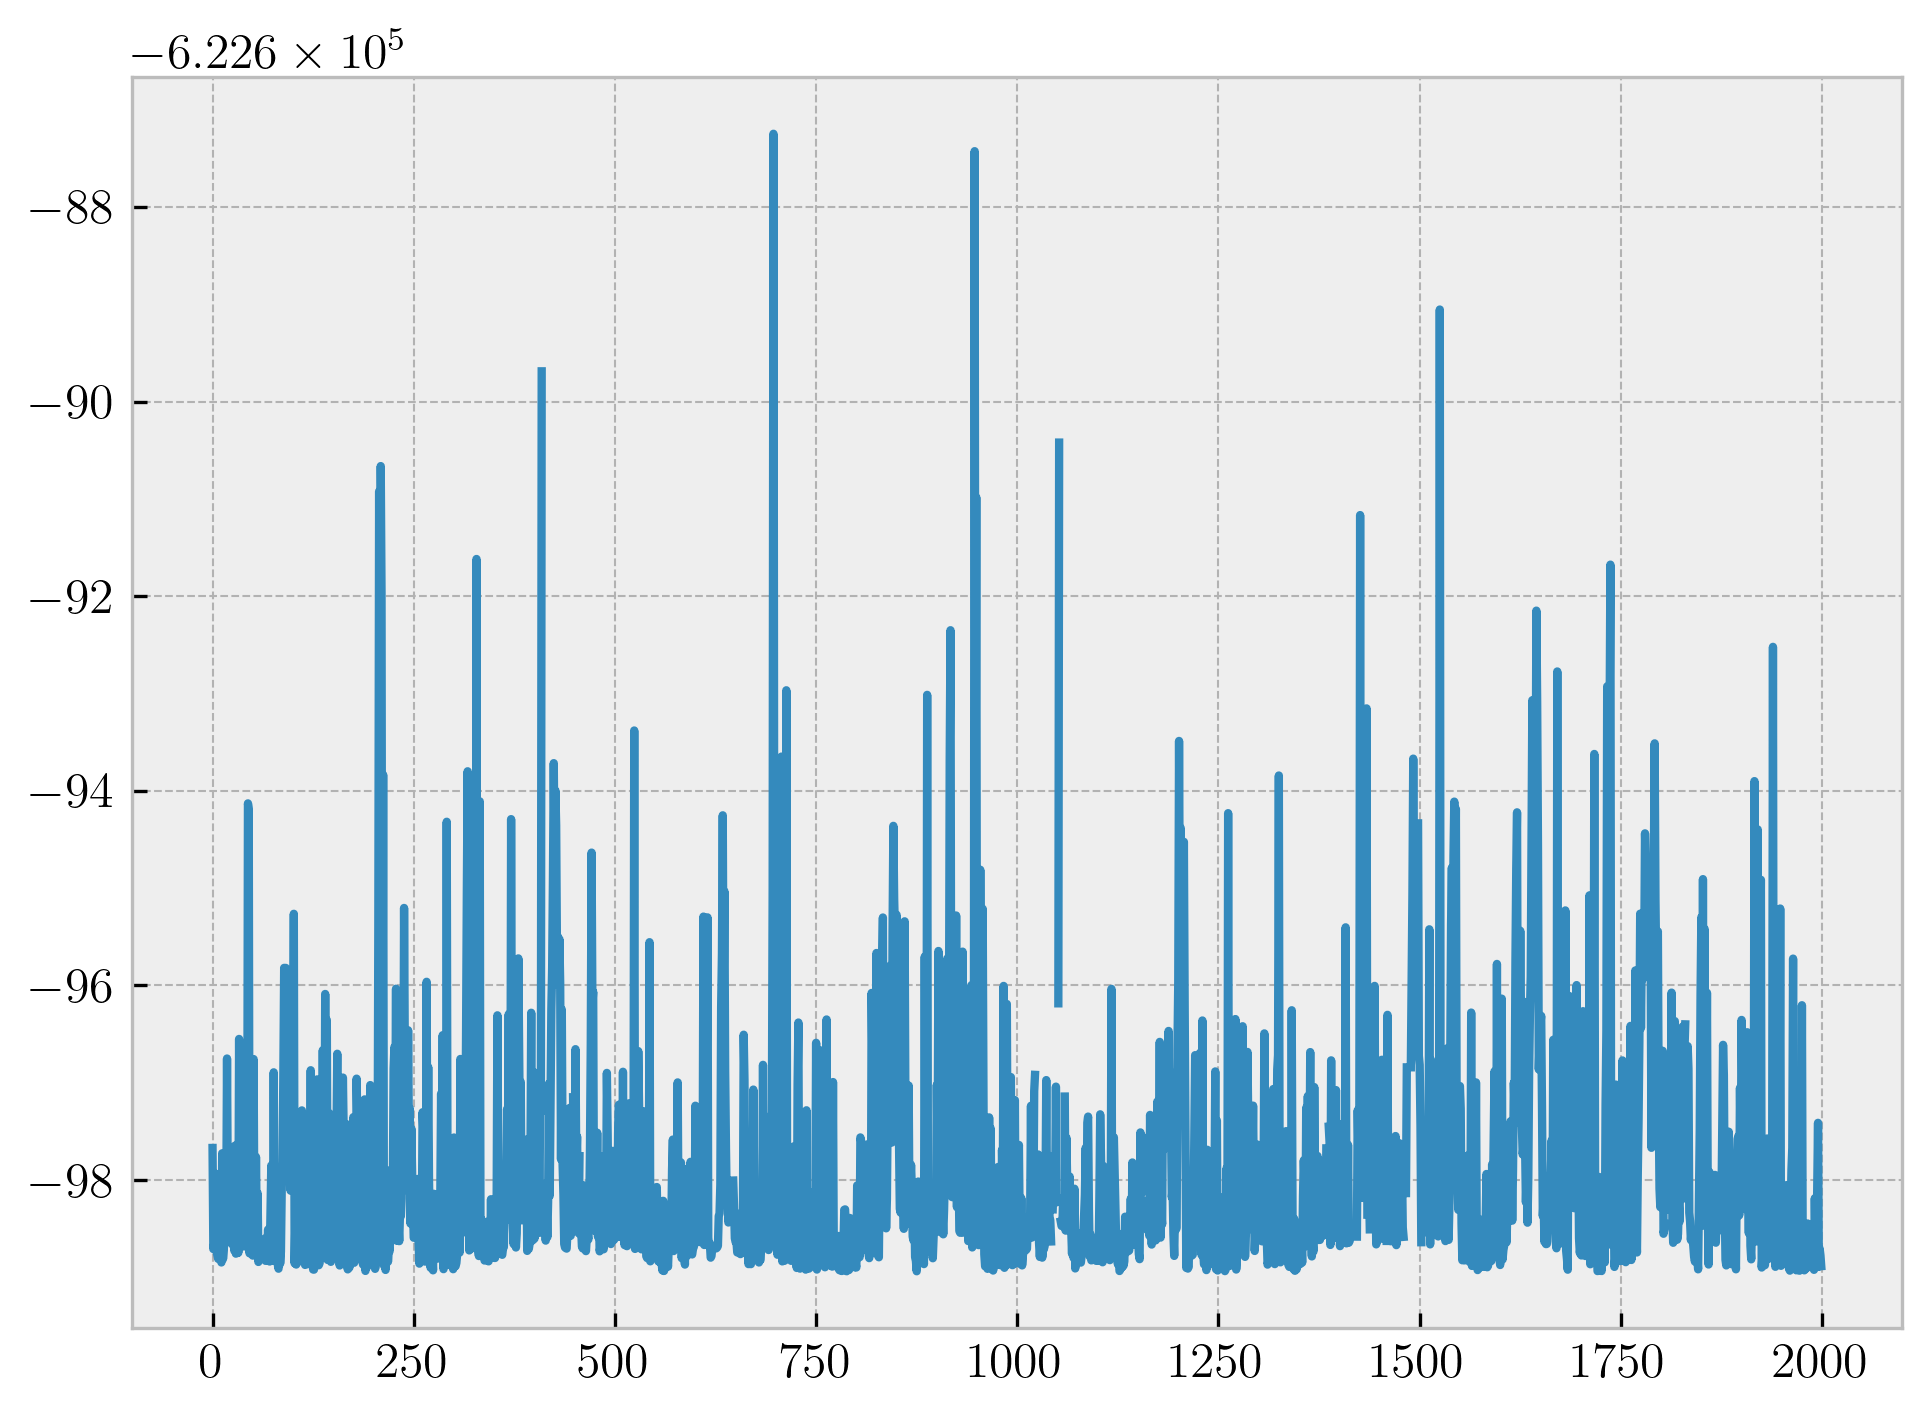

In [193]:
t = np.arange(0, n_samples)
plt.plot(t, result_a_1["log-posterior-trace"])

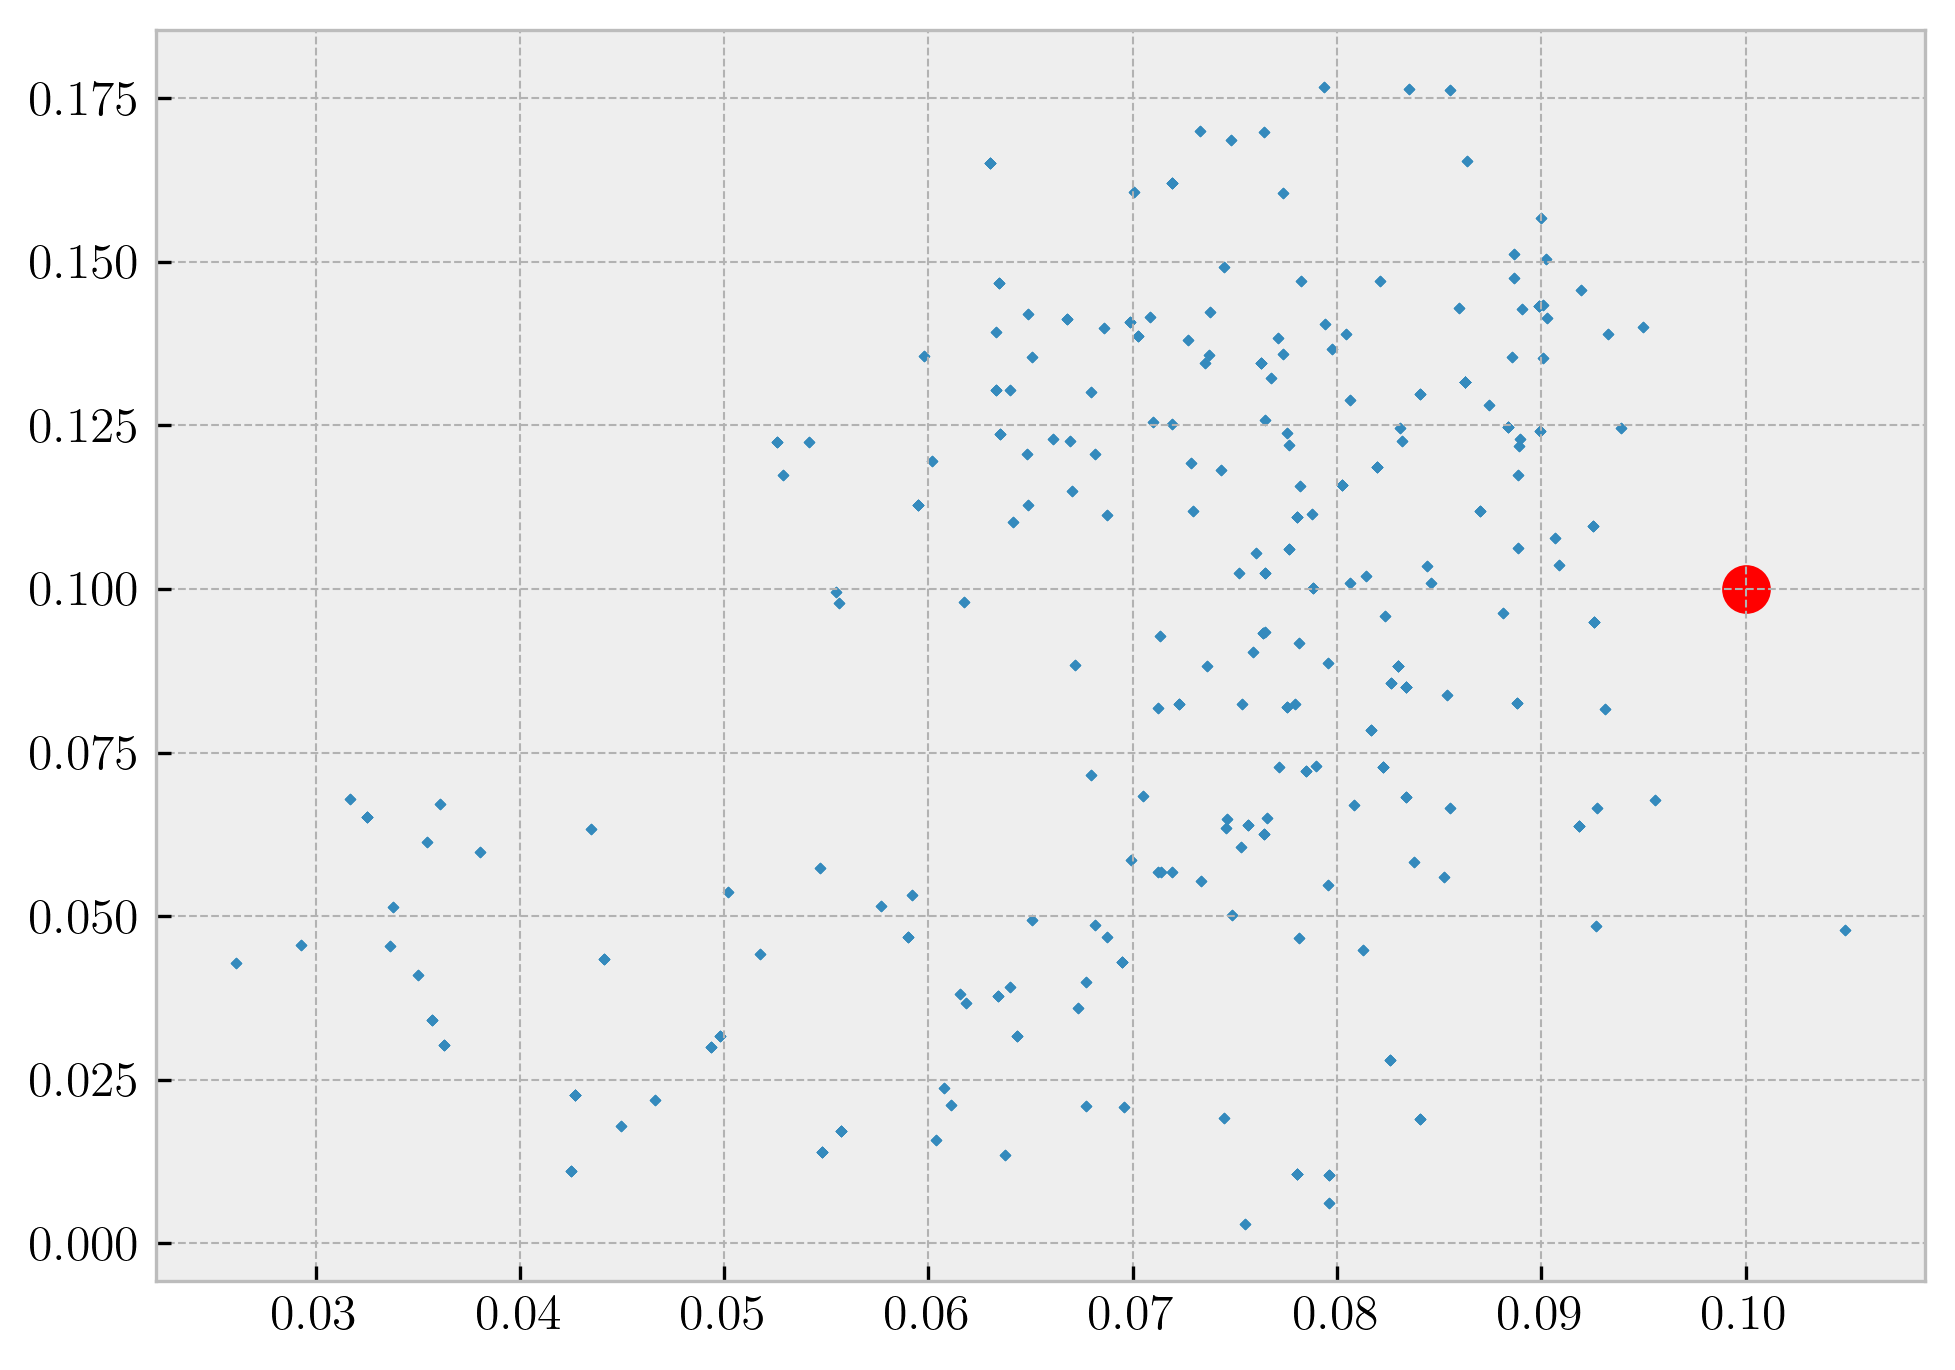

In [191]:
burn_in = 300
multi_data = result_a_1["a-trace"][-burn_in:]
mode_1 = result_a_1["a-trace"][:, 0][-burn_in:]
mode_2 = result_a_1["a-trace"][:, 1][-burn_in:]
fig, ax = plt.subplots(dpi = 300)
ax.scatter(mode_1, mode_2, marker = "x", s = 2)
ax.scatter(true_c[0], true_c[1], marker = ".", s = 500, c = "red")

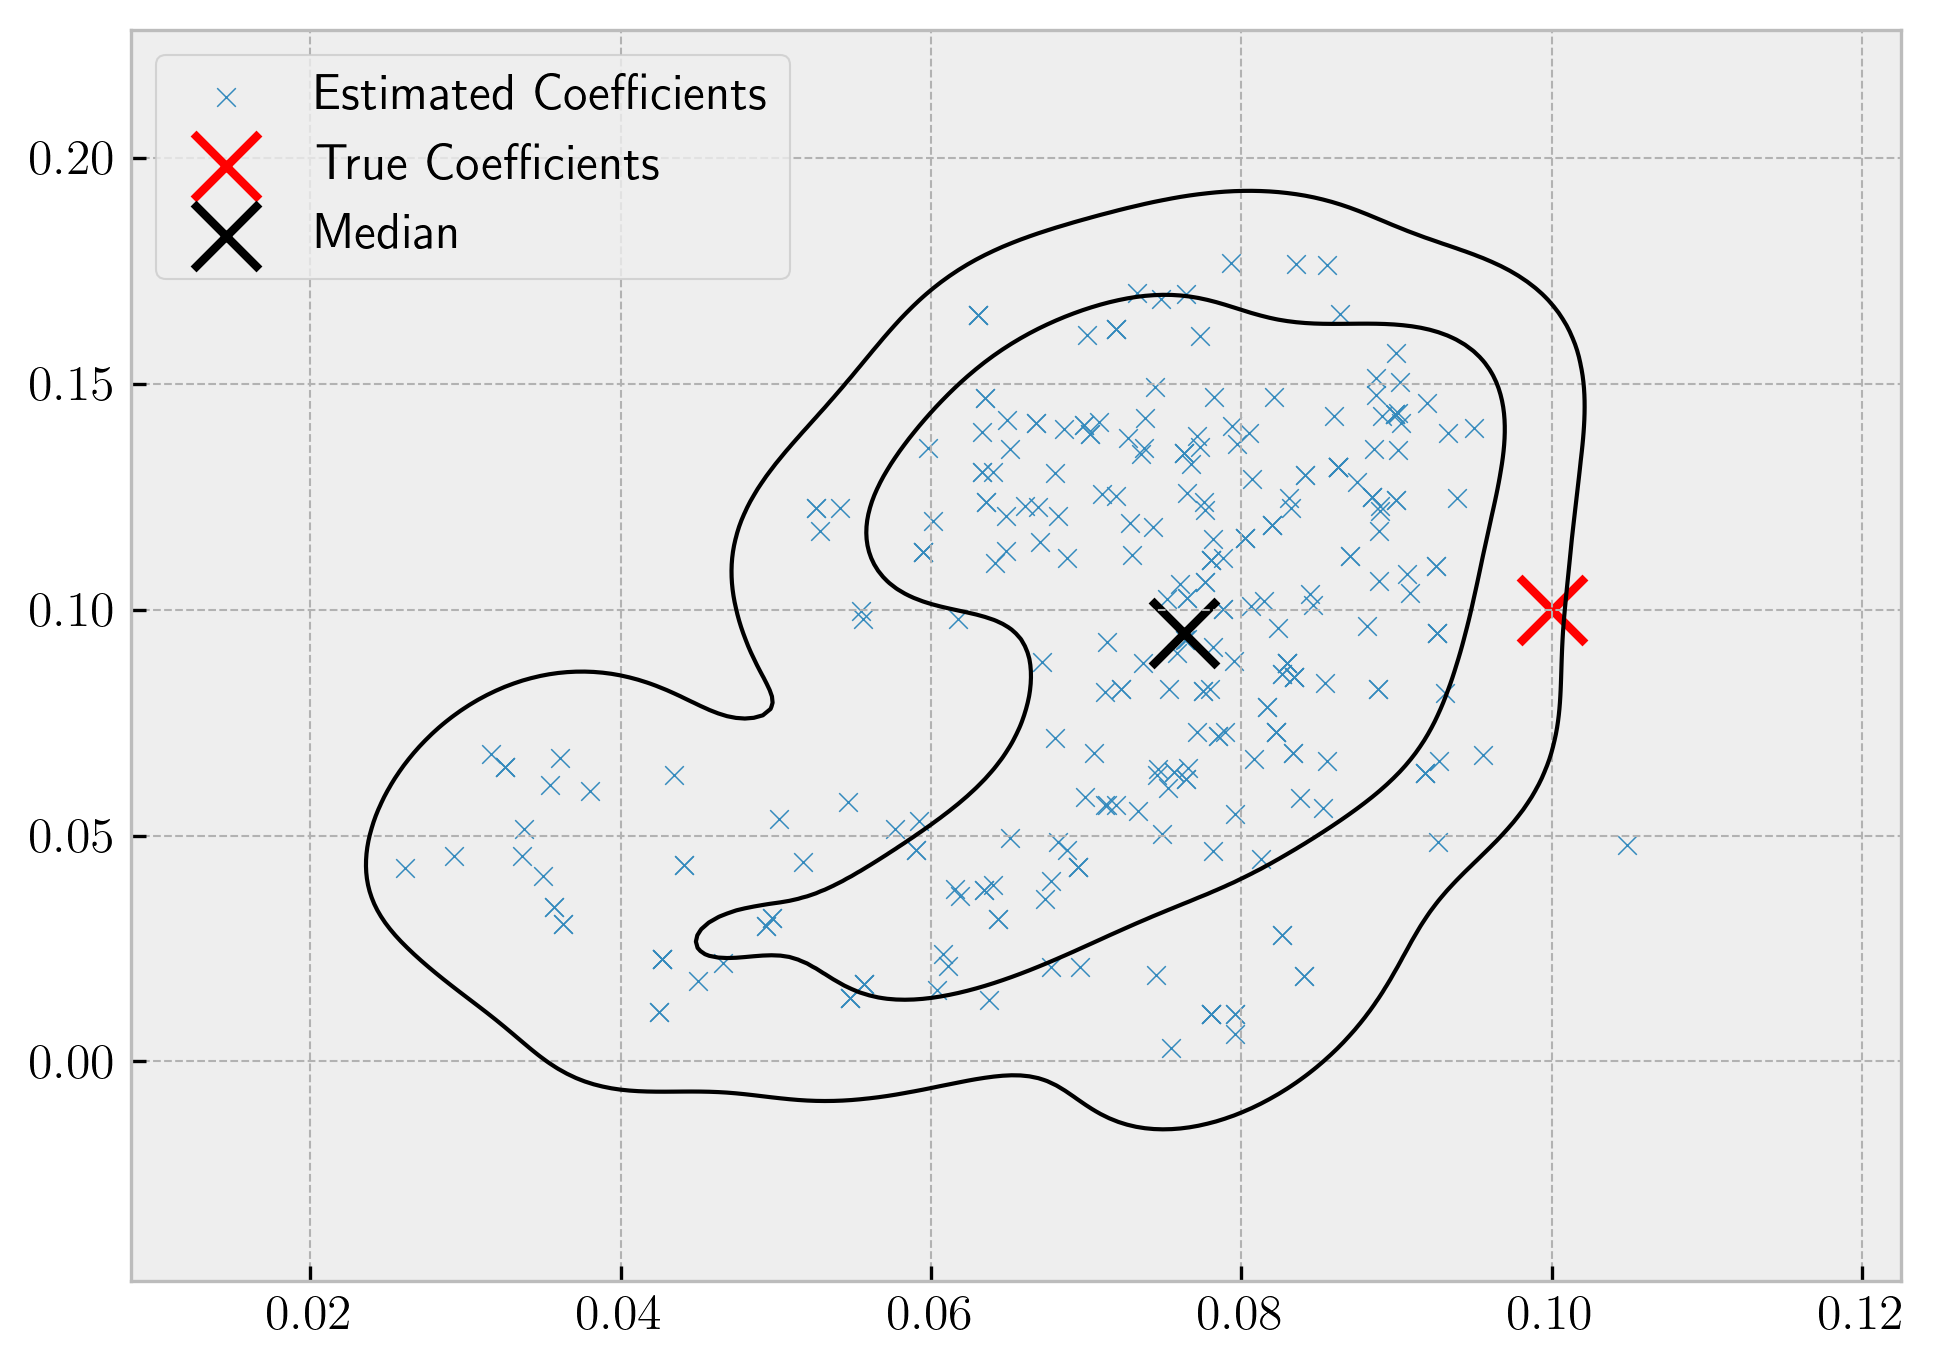

In [192]:
import seaborn as sns
fig, ax = plt.subplots()
sns.scatterplot(x=mode_1, y=mode_2, alpha=1.0, marker = "x", s = 20,
                ax = ax, label = "Estimated Coefficients")
sns.kdeplot(x=mode_1, y=mode_2, levels=[.05, 0.33], color="black", linewidths=1,
            ax = ax, label = "Contours")
ax.scatter(x=true_c[0], y=true_c[1], s = 250, marker = "x", c = "red", label = "True Coefficients")
ax.scatter(x= np.median(mode_1), y = np.median(mode_2), color = "black", label = "Median", marker = "x", s = 250)
ax.set_xlabel("")
ax.legend()
